In [2]:
import pandas as pd

In [3]:
import sqlite3

conn = sqlite3.connect("college.db")

In [4]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect("college.db")

In [6]:
import pandas as pd
import sqlite3

# Database connection
conn = sqlite3.connect("college.db")

# Students data
students_data = {
    'student_id': [1,2,3,4,5,6,7,8],

    'name': [
        'Oviya','Rahul','Ananya','Kavin',
        'Priya','Arun','Meena','Surya'
    ],

    'department': [
        'CS','EC','ME','CE',
        'CS','EC','ME','CE'
    ],

    'gender': [
        'Female','Male','Female','Male',
        'Female','Male','Female','Male'
    ],

    'math_score': [95,80,78,88,92,75,81,89],

    'programming_score': [98,70,65,85,90,72,60,87],

    'attendance_percentage': [90,85,88,92,95,80,84,91]
}

# Create DataFrame
students_df = pd.DataFrame(students_data)

# Store into SQL table
students_df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)

print("students table created successfully")

students table created successfully


In [7]:
q1 = """
SELECT AVG(programming_score) AS avg_programming
FROM students
WHERE gender = 'Female';
"""

result = pd.read_sql_query(q1, conn)

print(result)

   avg_programming
0            78.25


In [8]:
q2_where = """
SELECT *
FROM students
WHERE attendance_percentage > 85;
"""

result = pd.read_sql_query(q2_where, conn)

print(result)

   student_id    name department  gender  math_score  programming_score  \
0           1   Oviya         CS  Female          95                 98   
1           3  Ananya         ME  Female          78                 65   
2           4   Kavin         CE    Male          88                 85   
3           5   Priya         CS  Female          92                 90   
4           8   Surya         CE    Male          89                 87   

   attendance_percentage  
0                     90  
1                     88  
2                     92  
3                     95  
4                     91  


In [9]:
q2_having = """
SELECT department,
       AVG(attendance_percentage) AS avg_attendance
FROM students
GROUP BY department
HAVING AVG(attendance_percentage) > 85;
"""

result = pd.read_sql_query(q2_having, conn)

print(result)

  department  avg_attendance
0         CE            91.5
1         CS            92.5
2         ME            86.0


In [10]:
q3 = """
SELECT department,
       AVG(attendance_percentage) AS avg_attendance
FROM students
GROUP BY department
HAVING AVG(attendance_percentage) > 85;
"""

result = pd.read_sql_query(q3, conn)

print(result)

  department  avg_attendance
0         CE            91.5
1         CS            92.5
2         ME            86.0


In [11]:
print("""
pd.read_sql_query() returns a Pandas DataFrame.

Syntax:
pd.read_sql_query(sql_query, conn)

Arguments:
1. sql_query
2. conn
""")


pd.read_sql_query() returns a Pandas DataFrame.

Syntax:
pd.read_sql_query(sql_query, conn)

Arguments:
1. sql_query
2. conn



  department  avg_programming
0         CE             86.0
1         CS             94.0
2         EC             71.0
3         ME             62.5


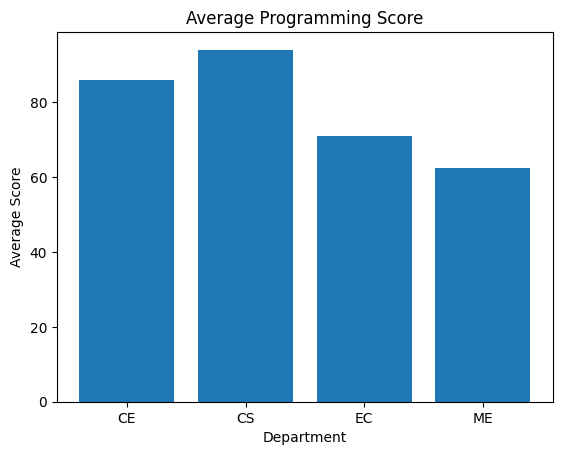

In [12]:
q5 = """
SELECT department,
       AVG(programming_score) AS avg_programming
FROM students
GROUP BY department;
"""

result = pd.read_sql_query(q5, conn)

print(result)

import matplotlib.pyplot as plt

plt.bar(
    result['department'],
    result['avg_programming']
)

plt.title("Average Programming Score")
plt.xlabel("Department")
plt.ylabel("Average Score")

plt.show()

In [14]:
dept_data = {
    'dept_code': ['CS', 'EC', 'ME', 'CE'],
    'dept_name': ['CS', 'EC', 'ME', 'CE'],
    'dept_head': ['Dr. Sharma', 'Dr. Reddy', 'Dr. Patel', 'Dr. Kumar'],
    'year': [1985, 1988, 1972, 1965],
    'intake': [60, 60, 60, 60]
}

dept_df = pd.DataFrame(dept_data)

dept_df.to_sql(
    'departments',
    conn,
    if_exists='replace',
    index=False
)

print("departments table created successfully")

departments table created successfully


In [15]:
inner_join = """
SELECT s.name,
       s.department,
       d.dept_head
FROM students s
INNER JOIN departments d
ON s.department = d.dept_name;
"""

result = pd.read_sql_query(inner_join, conn)

print(result)

     name department   dept_head
0   Oviya         CS  Dr. Sharma
1   Rahul         EC   Dr. Reddy
2  Ananya         ME   Dr. Patel
3   Kavin         CE   Dr. Kumar
4   Priya         CS  Dr. Sharma
5    Arun         EC   Dr. Reddy
6   Meena         ME   Dr. Patel
7   Surya         CE   Dr. Kumar


In [16]:
left_join = """
SELECT s.name,
       s.department,
       d.dept_head
FROM students s
LEFT JOIN departments d
ON s.department = d.dept_name;
"""

result = pd.read_sql_query(left_join, conn)

print(result)

     name department   dept_head
0   Oviya         CS  Dr. Sharma
1   Rahul         EC   Dr. Reddy
2  Ananya         ME   Dr. Patel
3   Kavin         CE   Dr. Kumar
4   Priya         CS  Dr. Sharma
5    Arun         EC   Dr. Reddy
6   Meena         ME   Dr. Patel
7   Surya         CE   Dr. Kumar


In [17]:
cross_join = """
SELECT s.name,
       d.dept_name
FROM students s
CROSS JOIN departments d;
"""

result = pd.read_sql_query(cross_join, conn)

print(result)

      name dept_name
0    Oviya        CS
1    Oviya        EC
2    Oviya        ME
3    Oviya        CE
4    Rahul        CS
5    Rahul        EC
6    Rahul        ME
7    Rahul        CE
8   Ananya        CS
9   Ananya        EC
10  Ananya        ME
11  Ananya        CE
12   Kavin        CS
13   Kavin        EC
14   Kavin        ME
15   Kavin        CE
16   Priya        CS
17   Priya        EC
18   Priya        ME
19   Priya        CE
20    Arun        CS
21    Arun        EC
22    Arun        ME
23    Arun        CE
24   Meena        CS
25   Meena        EC
26   Meena        ME
27   Meena        CE
28   Surya        CS
29   Surya        EC
30   Surya        ME
31   Surya        CE
